In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

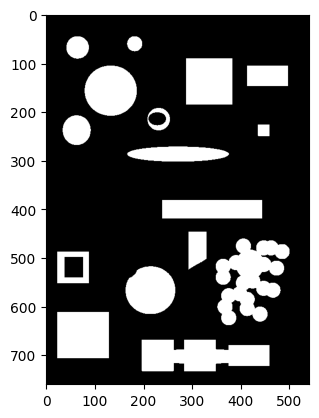

In [2]:
placa_rgb = cv.imread("/Users/miguelcamargorojas/Documents/UP/PDI - Ene-may25/images/detect_blob.png")[:,:,::-1]
placa_gray = cv.cvtColor(placa_rgb, cv.COLOR_RGB2GRAY)
placa_bin = cv.threshold(placa_gray, 0, 255, cv.THRESH_BINARY | cv.THRESH_OTSU)[1]
plt.imshow(placa_bin, "gray")
plt.show()

In [3]:
cv.CV_16U

2

In [4]:
output = cv.connectedComponentsWithStats(placa_bin)

In [5]:
type(output)

tuple

In [6]:
len(output)

4

In [7]:
numLabels, labels, stats, centroids = output

In [8]:
numLabels

18

In [11]:
output = placa_rgb.copy()

# loop over the number of unique connected component labels
for i in range(1, numLabels):
    text = "examining component {}/{}".format( i + 1, numLabels)
    # print a status message update for the current connected
    # component
    print("[INFO] {}".format(text))
    # extract the connected component statistics and centroid for
    # the current label
    x = stats[i, cv.CC_STAT_LEFT]
    y = stats[i, cv.CC_STAT_TOP]
    w = stats[i, cv.CC_STAT_WIDTH]
    h = stats[i, cv.CC_STAT_HEIGHT]
    area = stats[i, cv.CC_STAT_AREA]
    (cX, cY) = centroids[i]

    # clone our original image (so we can draw on it) and then draw
	# a bounding box surrounding the connected component along with
	# a circle corresponding to the centroid
    
    cv.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv.circle(output, (int(cX), int(cY)), 4, (255, 0, 0), -1)

[INFO] examining component 2/18
[INFO] examining component 3/18
[INFO] examining component 4/18
[INFO] examining component 5/18
[INFO] examining component 6/18
[INFO] examining component 7/18
[INFO] examining component 8/18
[INFO] examining component 9/18
[INFO] examining component 10/18
[INFO] examining component 11/18
[INFO] examining component 12/18
[INFO] examining component 13/18
[INFO] examining component 14/18
[INFO] examining component 15/18
[INFO] examining component 16/18
[INFO] examining component 17/18
[INFO] examining component 18/18


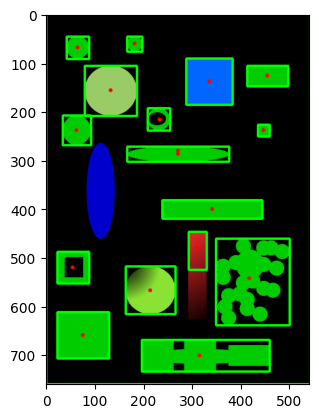

In [12]:
plt.imshow(output)
plt.show()